# Document Analysis with ColQwen2
[![arXiv](https://img.shields.io/badge/arXiv-2407.01449-b31b1b.svg?style=for-the-badge)](https://arxiv.org/abs/2407.01449)
[![Hugging Face](https://img.shields.io/badge/Vidore-FFD21E?style=for-the-badge&logo=huggingface&logoColor=000)](https://huggingface.co/vidore)

**So why did I spend my time playing with this?**
On one of the cognitively eventful Friday, I was thrown into terms like ColBERT and late interaction retrieval while discussing document parsing using `ColPali`, which led me to the [anchoring effect](https://en.wikipedia.org/wiki/Anchoring_effect) cognitive bias—i.e., I ended up translating it into the single vector embedding theory that I’m familiar with from [word2vec](https://n03an.me/Embeddings.html)... That was disturbing 😏

**ColBERT (Contextualized Late Interaction over BERT)** is a retrieval framework that generates **multi-vector embeddings** for queries and documents by preserving token-level embeddings. It uses a **late interaction mechanism**: computes similarity scores between individual query and document tokens (via max-pooling over token-wise dot products).  

### 🤷‍♂️ why are we talking ColBERT?
- **ColPali** and **ColQwen** extend ColBERT’s late interaction to **vision-language models (VLMs)**. You can say ColQwen2 is `Contextualized Late Interaction over Qwen2`.
- Instead of text-only embeddings, they generate **multi-vector representations for image patches and text tokens**.  
- **ColPali**: Built on **PaliGemma-3B** base model, which integrates:  
    - **SigLIP-So400m/14** (vision encoder) for image patch embeddings.  
    - **Gemma-1.1B** (decoder-only LLM) for text processing.  
    - Linear projection of image embeddings → LLM input space  
- **ColQwen**: Uses **Qwen2-VL**, a decoder-only model with:  
    - CLIP-style ViT → [Image Tokens]    
    - **Qwen2-7B** (decoder-only) for text processing
    - Vision-text integration uses cross-attention layers 

#### Finetuning Vision Language Models (VLMs) for Late Interaction Retrieval
Enhancing models retrieval capabilities, [LoRA](https://arxiv.org/abs/2106.09685) (Low-Rank Adaptation) and [PEFT](https://huggingface.co/docs/peft/index) (Parameter-Efficient Fine-Tuning) were used...

- **LoRA (Low-Rank Adaptation)**:  
  - Attach trainable low-rank layers to existing layers to learn task-specific patterns without modifying the original model weights
  - In ColPali/ColQwen: Applied to Language model layers (attention blocks, feed-forward networks) and Projection layers (vision-to-text alignment modules).  
```python
LoraConfig(
    r=64,  # Higher rank for vision-language tasks
    lora_alpha=128,  # Double the rank for stable scaling
    target_modules=["q_proj", "v_proj", "vision_proj"]
)
```
- **PEFT (Parameter-Efficient Fine-Tuning)**:  
  - Freezes pretrained model weights and updates only LoRA adapters.  
  - Why? 
    - Reduces memory usage and computational costs while retaining model performance
    - Preserving the model's broad knowledge base 

#### ⚠️ Note
PaliGemma VLM backbone can only take one image input at a time. Consequently, the document RAG pipeline will only be capble of using a top-1 page context for generation. Hence would experiemnt with ColQwen2 instead

[*ColQwen2*](https://x.com/ManuelFaysse/status/1839657285053788483): 
- ColQwen2 was trained with [LoRA](https://huggingface.co/docs/peft/main/en/conceptual_guides/lora), which allows to use adapter hot-swapping to switch between:
    1. Using the pre-trained adapter for creating the document embeddings used for retrieval
    2. Unload the adapter and use the backbone VLM for image-grounded generation.

![document RAG](./doc_RAG.png)

[`colpali-engine`](https://github.com/illuin-tech/colpali): the official implementation of ColPali and ColQwen2. This package also contains the training code (processor, collator, trainer...) for fine-tuning these models on your own dataset.

In [ ]:
# Ensure python version to be 3.12.4 or higher
!pip install -q -U "colpali-engine>=0.3.1,<0.4.0" requests


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from io import BytesIO
from typing import Any, List, cast

import torch
from colpali_engine.models import ColQwen2, ColQwen2Processor
from colpali_engine.utils.torch_utils import get_torch_device
from IPython.display import display
from peft import LoraConfig
from PIL import Image
from transformers.models.qwen2_vl import Qwen2VLForConditionalGeneration, Qwen2VLProcessor

/Users/n0man/Code/machine-learning/agents/agents-playground/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### NOTE: 
Because ColQWen2 uses dynamic resolution, would be better to scale down the images to prevent VRAM overload and faster inference times for both indexing and generation.

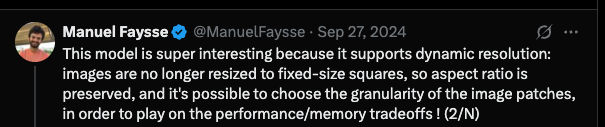


In [ ]:
def scale_image(image, new_height = 1024):
    width, height = image.size
    aspect_ratio = width / height
    new_width = int(new_height * aspect_ratio)

    scaled_image = image.resize((new_width, new_height))

    return scaled_image

#### Input Document
A sample of a legal case from The Federal Court of Canada case law database. See [1MM-1091-10](./2010fc1196.pdf) for the full document. We will use various image snapsots of the case as input to the model.

Image 0:


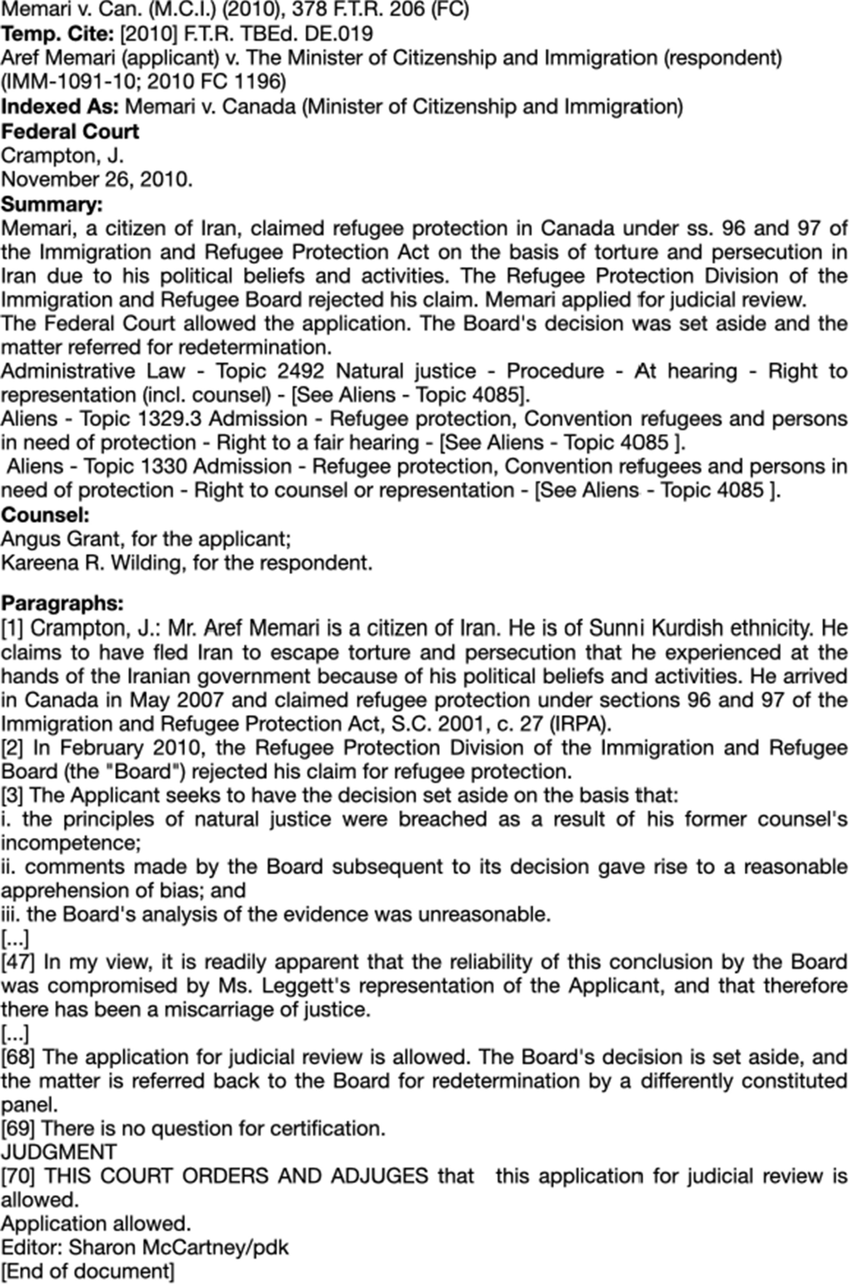

Image 1:


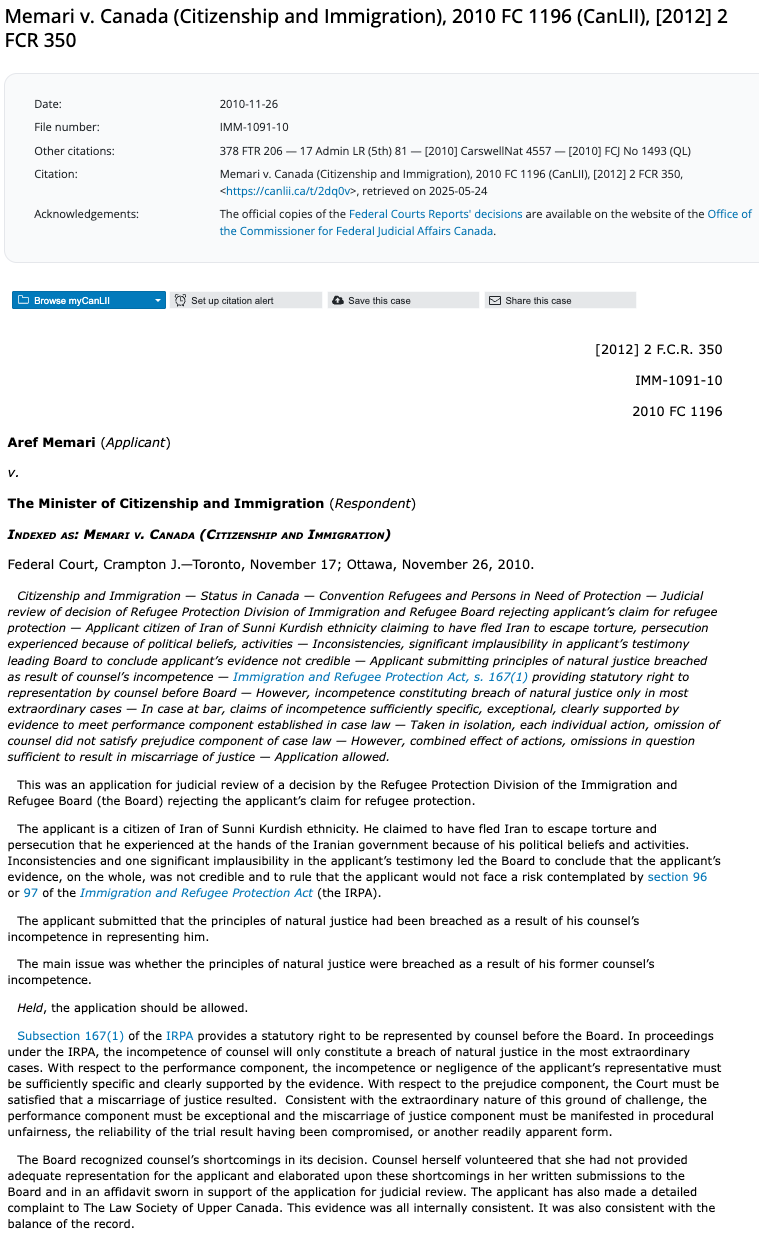

Image 2:


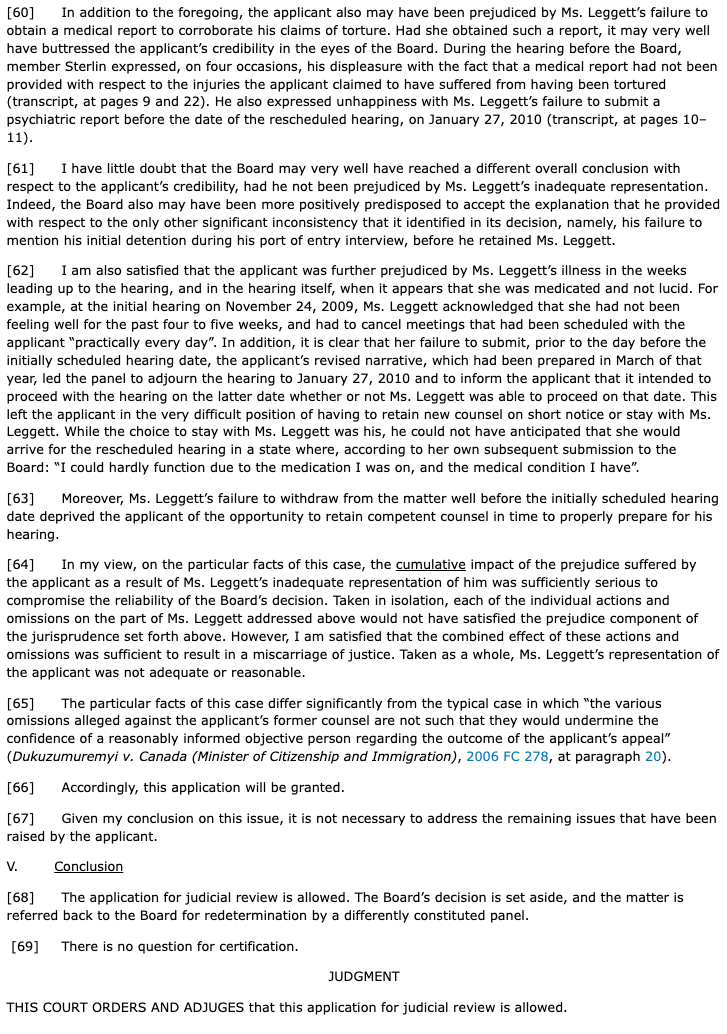

In [56]:
# query = "What is the ethinicity of the citizen ?"
queries = [
    "What is the ethinicity of the citizen?",
    "what is the final Judgement?",
    "what is the file number?"
]

images: List[Image.Image] = [
    Image.open("main_1.png"),
    Image.open("2.png"),
    # Image.open("3.png"),
    # Image.open("4.png"),
    # Image.open("5.png"),
    # Image.open("6.png"),
    # Image.open("7.png"),
    Image.open("8.png"),
]
print(f'Image 0:')
display(images[0])
print(f'Image 1:')
display(images[1])
print(f'Image 2:')
display(images[2])

images = [scale_image(image, new_height=512) for image in images]

#### The `DocumentPipelineRAG` class

- Wraps the original `ColQwen2` model
- Hides the complexity behind adapter handling
- Provides a simple API to switch between the retrieval and the generation modes

In [ ]:
"""
                    [DocumentPipelineRAG]
                              │
               ┌──────────────┴──────────────┐
               │                             │
      ┌───────────────────┐         ┌───────────────────┐
      |     ColQwen2      |         |      Qwen2VL      |
      | (Retrieval Mode)  |         |  (Generation Mode)|
      └───────────────────┘         └───────────────────┘
               │                             │
        LoRA Adapters (ON)        Base Model (Adapters OFF)
       (Efficient Fine-tuning)            Text or Answer
       Optimized for document              Generation
          understanding
"""

class DocumentPipelineRAG(ColQwen2):
    # Dual-mode Document RAG pipeline inherits from ColQwen2
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.is_retrieval = True

    def forward(self, *args, **kwargs) -> Any:
        """
        Forward pass based on the current mode:
        1) `Qwen2VLForConditionalGeneration.forward` for generation
        2) `ColQwen2.forward` for retrieval
        """
        if self.is_retrieval:
            return ColQwen2.forward(self, *args, **kwargs)
        else:
            return Qwen2VLForConditionalGeneration.forward(self, *args, **kwargs)

    def generate(self, *args, **kwargs):
        # Generate text using Qwen2VLForConditionalGeneration.generate.
        if self.is_retrieval:
            raise ValueError(
                "Set the model to generation mode by calling `enable_generation()` before calling `generate()`."
            )
        return super().generate(*args, **kwargs)

    def enable_retrieval(self):
        super().enable_adapters()
        self.is_retrieval = True
        
    def enable_generation(self):
        super().disable_adapters()
        self.is_retrieval = False

### Load ColQwen2 model

**Model Card** [`vidore/colqwen2-v1.0`](https://huggingface.co/vidore/colqwen2-v1.0).

#### Retrieval Processor:
- Handles multimodal inputs (text + images)
- Optimized for document understanding
- Trained using LoRA adapters

#### Generation Processor:
- Focused on text processing
- Used for answer generation
- Base model without LoRA adapters

In [ ]:
model_name = "vidore/colqwen2-v1.0"
device = get_torch_device("auto")

# mps for apple silicon
print(f"Using device: {device}")

# Get the LoRA config from the pretrained retrieval model
lora_config = LoraConfig.from_pretrained(model_name)

# Load the processors
processor_retrieval = ColQwen2Processor.from_pretrained(model_name)
print(f"Processor for retrieval loaded from {model_name}")
processor_generation = Qwen2VLProcessor.from_pretrained(lora_config.base_model_name_or_path)
print(f"Processor for generation loaded from {lora_config.base_model_name_or_path}")

# Load the model with the loaded pre-trained adapter for retrieval
model = DocumentPipelineRAG.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map=device,
)

Using device: mps
Processor for retrieval loaded from vidore/colqwen2-v1.0
Processor for generation loaded from vidore/colqwen2-base


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.41s/it]


## Document RAG Pipeline: Retrieval

Keeping only the top-1 result to preserve execution profile. Can extent the value of `top_k` to more than 1 for better quality.

Query 1: What is the ethinicity of the citizen? - can be answered by the following images: [0, 1, 2] with the heigest score 12.7500 image


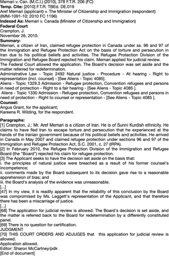

Query 2: what is the final Judgement? - can be answered by the following images: [0, 2, 1] with the heigest score 11.3750 image


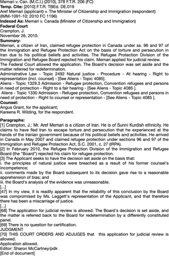

Query 3: what is the file number? - can be answered by the following images: [1, 2, 0] with the heigest score 12.6875 image


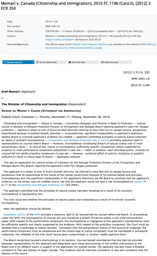

In [46]:
# Process the inputs
batch_images = processor_retrieval.process_images(images).to(model.device)
batch_queries = processor_retrieval.process_queries(queries).to(model.device)

# Forward pass
model.enable_retrieval()

with torch.no_grad():
    image_embeddings = model.forward(**batch_images)
    query_embeddings = model.forward(**batch_queries)

# Calculate the similarity scores
scores = processor_retrieval.score_multi_vector(query_embeddings, image_embeddings)

# Get indices of the top-3 highest scores
top_k = 3
top_indices = torch.topk(scores, k=top_k, dim=-1).indices.squeeze().tolist()

# Retrieve and display top images for each query
for i, query in enumerate(queries):
    print(f"Query {i+1}: {query} - can be answered by the following images: {top_indices[i]} with the heigest score {scores[i][top_indices[i][0]].item():.4f} image")
    display(scale_image(images[top_indices[i][0]], new_height=256))


## Augmented Generation

The retrival stage has provided us with the most relevant top-k images for the respective query text. In the Generation stage, we'll...
- Switch to generation mode by disabling the LoRA adapter
- Use the `generate` method to use Qwen2-VL to generate the answer the query using the top-1 image for that query.

In [51]:
conversations = []
relevant_input_images = []

for i, query in enumerate(queries):
    conversation = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": f"Answer the following question using the input image: {query}",
                },
            ],
        }
    ]
    text_prompt = processor_generation.apply_chat_template(conversation, add_generation_prompt=True)
    conversations.append(text_prompt)
    relevant_input_images.append(images[top_indices[i][0]])

inputs_generation = processor_generation(
    text=conversations,
    images=relevant_input_images,
    padding=True,
    return_tensors="pt",
).to(device)

# Generate the RAG response
model.enable_generation()
output_ids = model.generate(**inputs_generation, max_new_tokens=128)

# Ensure that only the newly generated token IDs are retained from output_ids
generated_ids = [output_ids[len(input_ids) :] for input_ids, output_ids in zip(inputs_generation.input_ids, output_ids)]

# Decode the RAG response
output_text = processor_generation.batch_decode(
    generated_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True,
)

# Present results
for idx, query in enumerate(queries):
    print(f"\n=== Response {idx+1} ===")
    print(f"Query: {query}")
    print(f"Answer: {output_text[idx]}")

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



=== Response 1 ===
Query: What is the ethinicity of the citizen?
Answer: The citizen is of Sunni Kurdish ethnicity.

=== Response 2 ===
Query: what is the final Judgement?
Answer: The final judgement is that this application for judicial review is allowed.

=== Response 3 ===
Query: what is the file number?
Answer: The file number is 1MM-1091-10.
